In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
def generate_data(n=1000, d=10):
    X = np.random.randn(n, d)
    true_w = np.random.randn(d)
    logits = X @ true_w
    y = (logits > 0).astype(int)
    return X, y

X, y = generate_data()
n, d = X.shape

In [3]:
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1 / (1 + np.exp(-z))

def grad_i(w, x_i, y_i):
    p = sigmoid(x_i @ w)
    return (p - y_i) * x_i

In [4]:
def full_gradient(w, X, y):
    n = X.shape[0]
    grad = np.zeros_like(w)
    for i in range(n):
        z = np.clip(X[i] @ w, -50, 50)
        p = 1 / (1 + np.exp(-z))
        grad += (p - y[i]) * X[i]
    return grad / n

In [5]:
def rmsprop(X, y, lr=0.01, epochs=20, beta=0.9, eps=1e-8):
    n, d = X.shape
    w = np.zeros(d)
    v = np.zeros(d)

    history = []

    for epoch in range(epochs):
        for _ in range(n):
            i = np.random.randint(0, n)

            g = grad_i(w, X[i], y[i])

            v = beta * v + (1 - beta) * (g ** 2)

            w -= lr * g / (np.sqrt(v) + eps)

        history.append(np.linalg.norm(full_gradient(w, X, y)))

    return w, history

In [6]:
w_rmsprop, hist_rmsprop = rmsprop(X, y, lr=0.01, epochs=30)

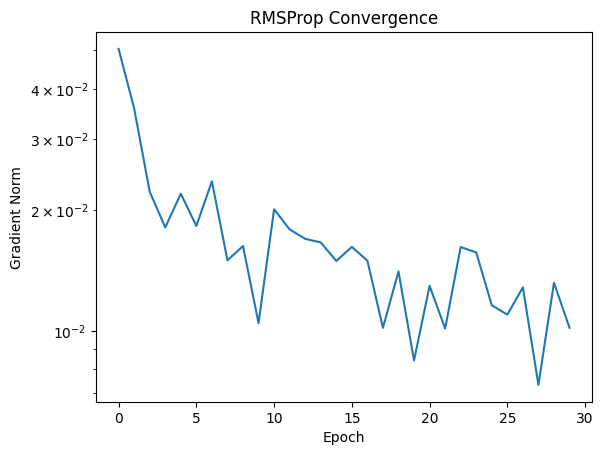

In [7]:
plt.plot(hist_rmsprop)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.title("RMSProp Convergence")
plt.show()